In [2]:
import sys
import subprocess

# Install packages needed for KMeans analysis in this notebook kernel

packages = ["scikit-learn", "numpy", "pandas", "matplotlib", "seaborn", "scipy"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

0

In [21]:
#importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder


In [4]:
df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [5]:
df.isnull().sum()


Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [7]:
df.dropna(inplace=True)
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

In [8]:
df.drop('Customer ID', axis=1, inplace=True)
df.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [9]:
gender_spending = df.groupby('Gender')['Total Spend'].sum().reset_index()
print(gender_spending)



   Gender  Total Spend
0  Female     122318.4
1    Male     172713.6


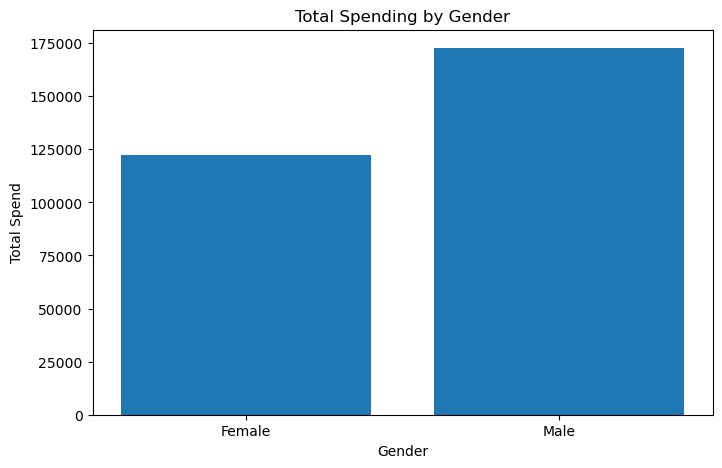

In [10]:
#visualizing the total spending by gender

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(gender_spending['Gender'], gender_spending['Total Spend'])

plt.title('Total Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spend')
plt.show()


In [11]:
age_spending = df.groupby('Age')['Total Spend'].sum().reset_index()
print(age_spending)

    Age  Total Spend
0    26      6205.40
1    27     17770.50
2    28     35812.40
3    29     14192.40
4    30     63631.00
5    31     28615.00
6    32     26579.90
7    33      8206.40
8    34     18985.10
9    35     20002.20
10   36     12522.80
11   37      9517.60
12   38      3998.10
13   41     11626.00
14   42      4668.45
15   43     12698.75


In [12]:
#visualizing the total spending by age using plotly

import plotly.express as px

fig = px.line(
    age_spending,
    x='Age',
    y='Total Spend',
    markers=True,
    title='Total Spend by Age'
)

fig.update_layout(
    xaxis_title='Age',
    yaxis_title='Total Spend (Currency)',
    hovermode='x unified'
)

fig.show()


C:\Users\BRIGHTMAN\AppData\Local\Temp\ipykernel_24936\1547113517.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




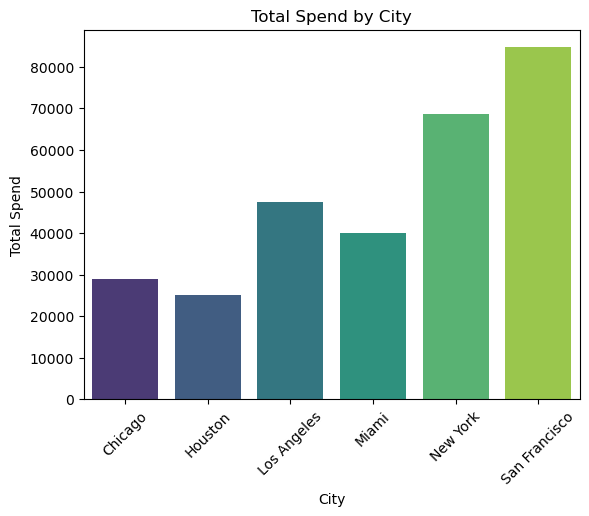

In [15]:
#visualizing the total spending by city using seaborn

total_spend_by_city = df.groupby('City')['Total Spend'].sum().reset_index()
sns.barplot(data=total_spend_by_city, x='City', y='Total Spend', palette='viridis')
plt.title('Total Spend by City')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#visualizing the total spending by membership type using plotly

membership_spend = df.groupby('Membership Type')['Total Spend'].sum().reset_index()

fig = px.bar(
    membership_spend,
    x="Membership Type",
    y="Total Spend",
    title="Total Spend by Membership Type",
    hover_data=["Total Spend"]
)

fig.show()


In [ ]:
df['Membership Type'].value_counts()

Membership Type
Gold      117
Silver    117
Bronze    114
Name: count, dtype: int64

In [ ]:
city_membership_counts = df.groupby(['City', 'Membership Type']).size().reset_index(name='Count')
city_membership_counts


,City,Membership Type,Count
0,Chicago,Bronze,58
1,Houston,Bronze,56
2,Los Angeles,Silver,59
3,Miami,Silver,58
4,New York,Gold,59
5,San Francisco,Gold,58


In [ ]:
#visualizing membership distribution by city using plotly

fig = px.bar(
    city_membership_counts,
    x="City",
    y="Count",
    color="Membership Type",
    barmode="group",
    title="Membership Distribution by City",
    hover_data=['Membership Type', 'Count']
)

fig.show()


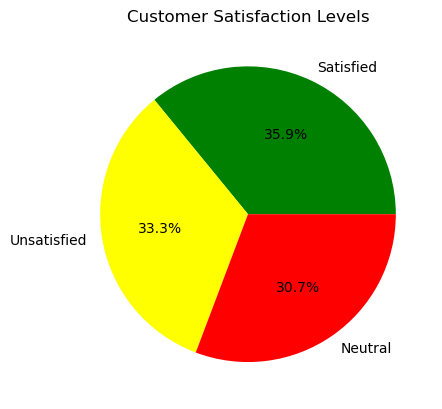

In [ ]:
# Pie chart for Satisfaction Level

df['Satisfaction Level'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green','yellow','red'])
plt.title('Customer Satisfaction Levels')
plt.ylabel('')
plt.show()


C:\Users\BRIGHTMAN\AppData\Local\Temp\ipykernel_24936\587922533.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




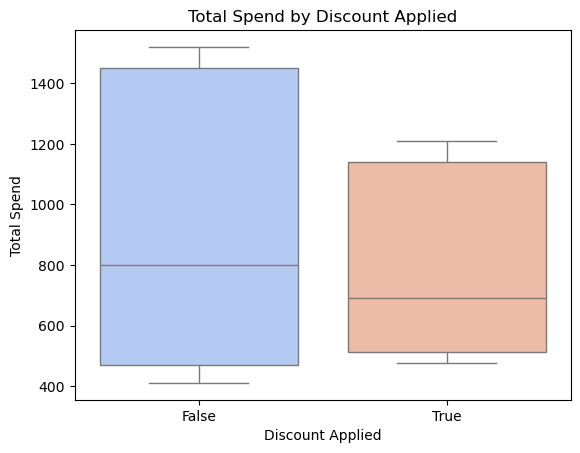

In [17]:
# Discount Applied vs Total Spend

import seaborn as sns
sns.boxplot(data=df, x='Discount Applied', y='Total Spend', palette='coolwarm')
plt.title('Total Spend by Discount Applied')
plt.show()

C:\Users\BRIGHTMAN\AppData\Local\Temp\ipykernel_25224\1959050762.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




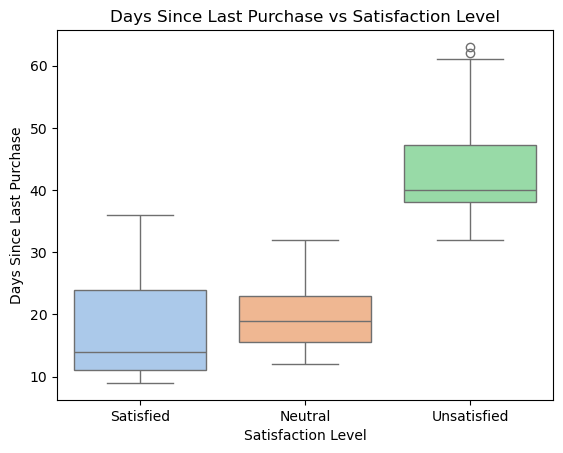

In [ ]:
# Days Since Last Purchase vs Satisfaction

sns.boxplot(data=df, x='Satisfaction Level', y='Days Since Last Purchase', palette='pastel')
plt.title('Days Since Last Purchase vs Satisfaction Level')
plt.show()

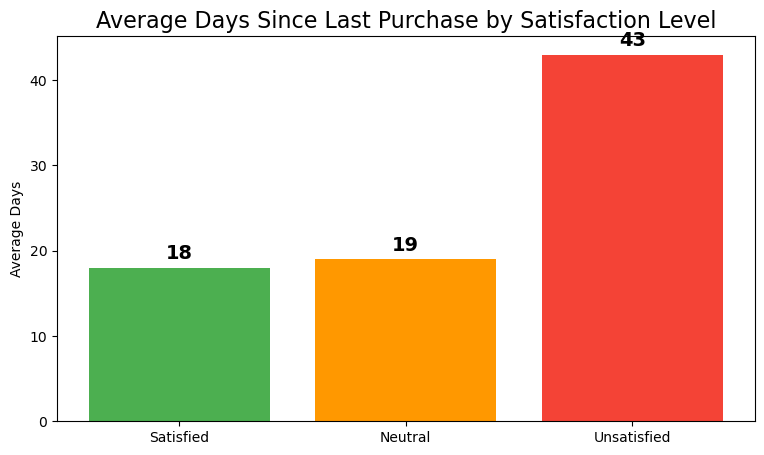

In [20]:
# Average Days Since Last Purchase by Satisfaction Level more understandable bar chart
avg_days = df.groupby('Satisfaction Level')['Days Since Last Purchase'].mean().round(0)
order = ['Satisfied', 'Neutral', 'Unsatisfied']

plt.figure(figsize=(9,5))
bars = plt.bar(order, avg_days.loc[order], color=['#4CAF50', '#FF9800', '#F44336'])
plt.title('Average Days Since Last Purchase by Satisfaction Level', fontsize=16)
plt.ylabel('Average Days')

for bar in bars:
    height = int(bar.get_height())
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, str(height), 
             ha='center', fontsize=14, fontweight='bold')

plt.show()

In [22]:
# Encoding Categorical Variables

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])                    # Female→0, Male→1
df['City'] = le.fit_transform(df['City'])                        # Alphabetical order
df['Discount Applied'] = df['Discount Applied'].astype(int)      # True→1, False→0 (already boolean)

# 2. Ordinal Encoding for columns that HAVE a natural order
membership_order = ['Bronze', 'Silver', 'Gold']
satisfaction_order = ['Unsatisfied', 'Neutral', 'Satisfied']

df['Membership Type'] = pd.Categorical(df['Membership Type'], 
                                        categories=membership_order, 
                                        ordered=True).codes
                                        # Bronze→0, Silver→1, Gold→2

df['Satisfaction Level'] = pd.Categorical(df['Satisfaction Level'], 
                                          categories=satisfaction_order, 
                                          ordered=True).codes
                                          # Unsatisfied→0, Neutral→1, Satisfied→2
# Check the result
print(df.head())
print("\nData types and unique values:")
print(df.dtypes)
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].unique())

   Gender  Age  City  Membership Type  Total Spend  Items Purchased  \
0       0   29     4                2      1120.20               14   
1       1   34     2                1       780.50               11   
2       0   43     0                0       510.75                9   
3       1   30     5                2      1480.30               19   
4       1   27     3                1       720.40               13   

   Average Rating  Discount Applied  Days Since Last Purchase  \
0             4.6                 1                        25   
1             4.1                 0                        18   
2             3.4                 1                        42   
3             4.7                 0                        12   
4             4.0                 1                        55   

   Satisfaction Level  
0                   2  
1                   1  
2                   0  
3                   2  
4                   0  

Data types and unique values:
Gender 

In [24]:
corr = df.corr()
corr


,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
Gender,1.000000,-0.581774,0.483359,0.405573,0.387471,0.439175,0.492687,-0.344872,-0.214256,0.037824
Age,-0.581774,1.000000,-0.876826,-0.790544,-0.676826,-0.684397,-0.721752,0.061262,0.170437,-0.463274
City,0.483359,-0.876826,1.000000,0.956099,0.921276,0.891535,0.887721,-0.099413,-0.403373,0.699398
Membership Type,0.405573,-0.790544,0.956099,1.000000,0.945334,0.896343,0.949810,-0.003588,-0.420431,0.741763
Total Spend,0.387471,-0.676826,0.921276,0.945334,1.000000,0.972276,0.941190,-0.168530,-0.544679,0.797494
Items Purchased,0.439175,-0.684397,0.891535,0.896343,0.972276,1.000000,0.921396,-0.123037,-0.425425,0.692850
Average Rating,0.492687,-0.721752,0.887721,0.949810,0.941190,0.921396,1.000000,-0.076756,-0.435921,0.694679
Discount Applied,-0.344872,0.061262,-0.099413,-0.003588,-0.168530,-0.123037,-0.076756,1.000000,0.760032,-0.425115
Days Since Last Purchase,-0.214256,0.170437,-0.403373,-0.420431,-0.544679,-0.425425,-0.435921,0.760032,1.000000,-0.773735
Satisfaction Level,0.037824,-0.463274,0.699398,0.741763,0.797494,0.692850,0.694679,-0.425115,-0.773735,1.000000


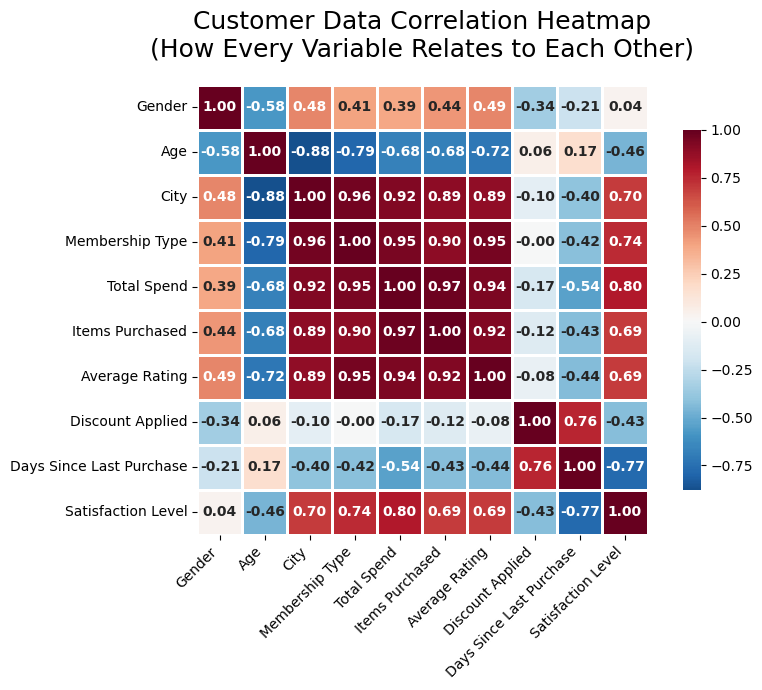

In [61]:
# Correlation Heatmap

plt.figure(figsize=(9, 7))
sns.heatmap(corr, 
            annot=True,          # shows the actual correlation values
            cmap='RdBu_r',       # red = negative, blue = positive, white = zero
            center=0,            # makes 0 white
            fmt='.2f',             # one decimal place
            linewidths=1,
            square=True,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10, "weight": "bold"})

plt.title('Customer Data Correlation Heatmap\n(How Every Variable Relates to Each Other)', 
          fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Prepare data for K-means

features = df.copy()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)
df_scaled

array([[-1.00576374, -0.93976119,  0.87245949, ...,  0.99426929,
        -0.12002211,  1.17114691],
       [ 0.99426929,  0.08671996, -0.29980268, ..., -1.00576374,
        -0.64026028, -0.0310924 ],
       [-1.00576374,  1.93438603, -1.47206485, ...,  0.99426929,
         1.14341345, -1.2333317 ],
       ...,
       [-1.00576374, -0.73446496,  0.87245949, ...,  0.99426929,
         0.10293711,  1.17114691],
       [ 0.99426929,  0.08671996, -0.29980268, ..., -1.00576374,
        -0.41730106, -0.0310924 ],
       [-1.00576374,  1.93438603, -1.47206485, ...,  0.99426929,
         1.66365162, -1.2333317 ]])

In [28]:
#  Find the best K with Elbow + Silhouette

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score

range_n_clusters = range(2, 11)
inertias = []
silhouette_avg = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(df_scaled, cluster_labels))

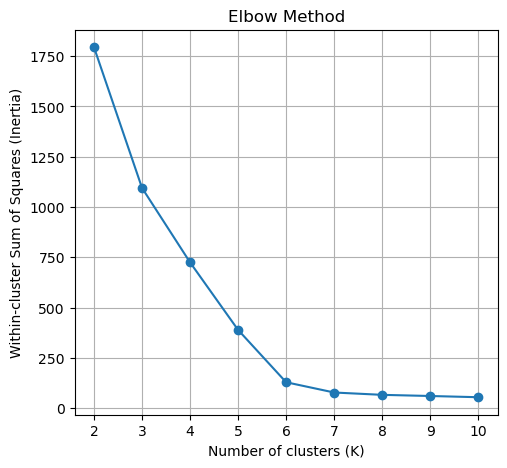

In [29]:
# Plot Elbow curve

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-cluster Sum of Squares (Inertia)')
plt.grid(True)

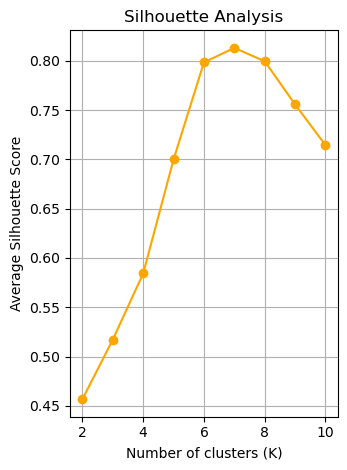

In [30]:
# Plot Silhouette scores
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg, marker='o', color='orange')
plt.title('Silhouette Analysis')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
# Choose the best K based on the plots

best_k = 4

# Final model with best K
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)
df['Cluster']

0      1
1      2
2      0
3      1
4      3
      ..
345    3
346    0
347    1
348    2
349    0
Name: Cluster, Length: 348, dtype: int32

In [46]:
# Quick look at the results 

print(f"\nFinal model uses K = {best_k}")
print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())

print("\nCluster centers (in original scale):")
centers_scaled = kmeans_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

# Use the feature column names (exclude the 'Cluster' column that was added to df)
centers_df = pd.DataFrame(centers_original, columns=features.columns)
print(centers_df.round(2))


Final model uses K = 4

Cluster sizes:
Cluster
0    114
1    117
2     59
3     58
Name: count, dtype: int64

Cluster centers (in original scale):
   Gender    Age  City  Membership Type  Total Spend  Items Purchased  \
0    0.00  39.40  0.49              0.0       474.22             8.52   
1    0.50  29.92  4.50              2.0      1311.14            17.62   
2    1.00  34.12  2.00              1.0       805.49            11.68   
3    0.98  28.95  3.00              1.0       690.39            11.64   

   Average Rating  Discount Applied  Days Since Last Purchase  \
0            3.33              0.51                     31.78   
1            4.68              0.50                     17.94   
2            4.17             -0.00                     15.27   
3            3.93              1.00                     45.50   

   Satisfaction Level  
0                0.49  
1                2.00  
2                1.14  
3               -0.00  


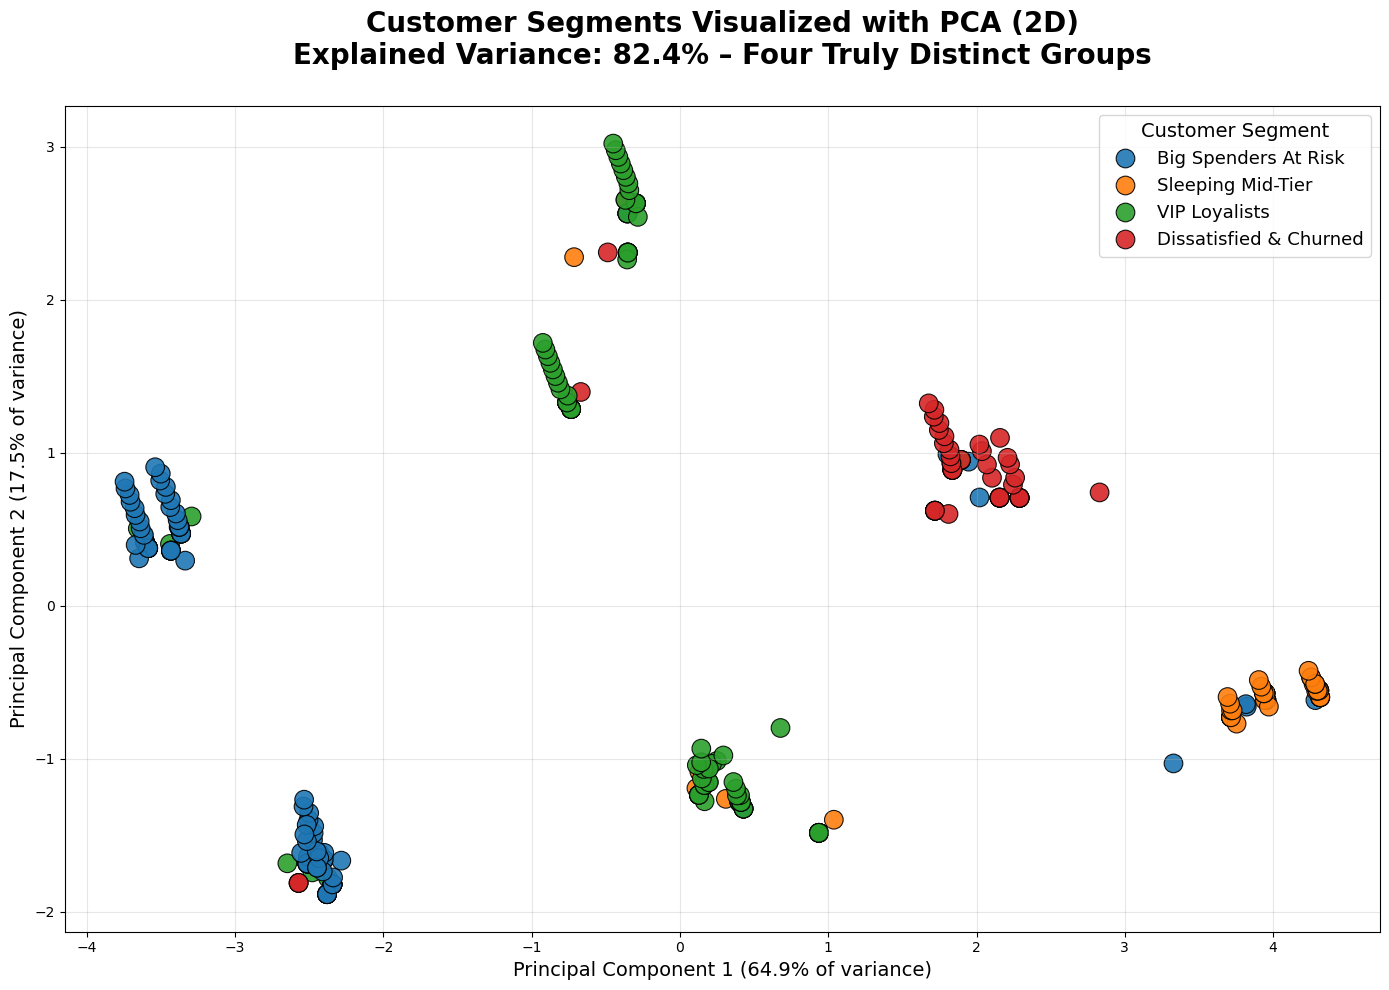

In [ ]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

segment_names = {
    0: 'VIP Loyalists',           # high spend, high rating, recent purchase
    1: 'Big Spenders At Risk',    # high spend, low rating
    2: 'Sleeping Mid-Tier',       # average everything
    3: 'Dissatisfied & Churned'   # low spend, low rating, long absence
}

pca_df['Segment'] = pca_df['Cluster'].map(segment_names)

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=pca_df, 
    x='PC1', y='PC2', 
    hue='Segment',
    palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],  # blue, orange, green, red
    s=180, 
    alpha=0.9, 
    edgecolor='black', 
    linewidth=0.8
)

plt.title('Customer Segments Visualized with PCA (2D)\nExplained Variance: 82.4% – Four Truly Distinct Groups', 
          fontsize=20, pad=30, weight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} of variance)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} of variance)', fontsize=14)
plt.legend(title='Customer Segment', title_fontsize=14, fontsize=13, loc='best')
plt.grid(True, alpha=0.3)

# Optional: save it in high quality
plt.tight_layout()
plt.savefig('Customer_Segments_PCA_Final.png', dpi=300, bbox_inches='tight')
plt.show()

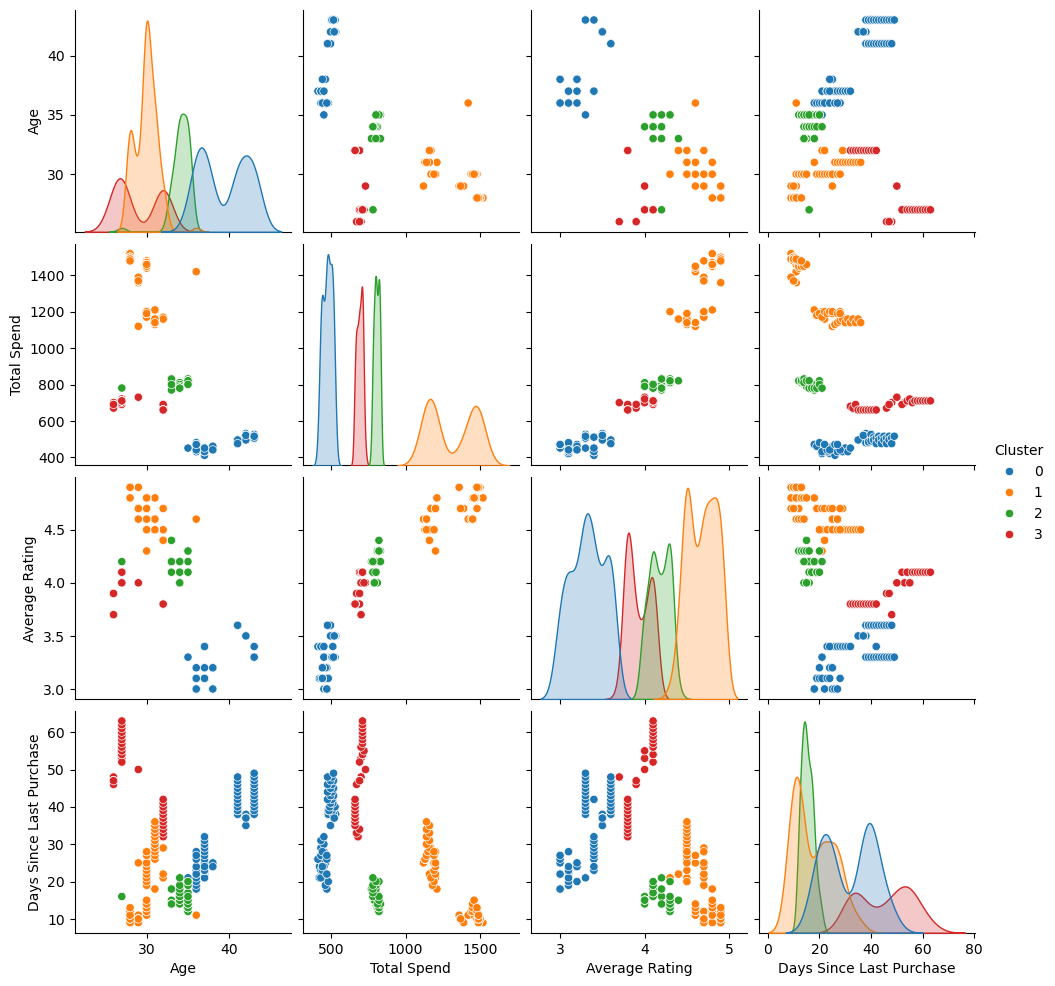

In [59]:
# 8. Bonus: Nice pairplot to visualize clusters (optional but beautiful)
sns.pairplot(df, hue='Cluster', vars=['Age', 'Total Spend', 'Average Rating', 'Days Since Last Purchase'], 
             palette='tab10', diag_kind='kde')
plt.show()

In [55]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [52]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [54]:
import joblib
joblib.dump(kmeans_final, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

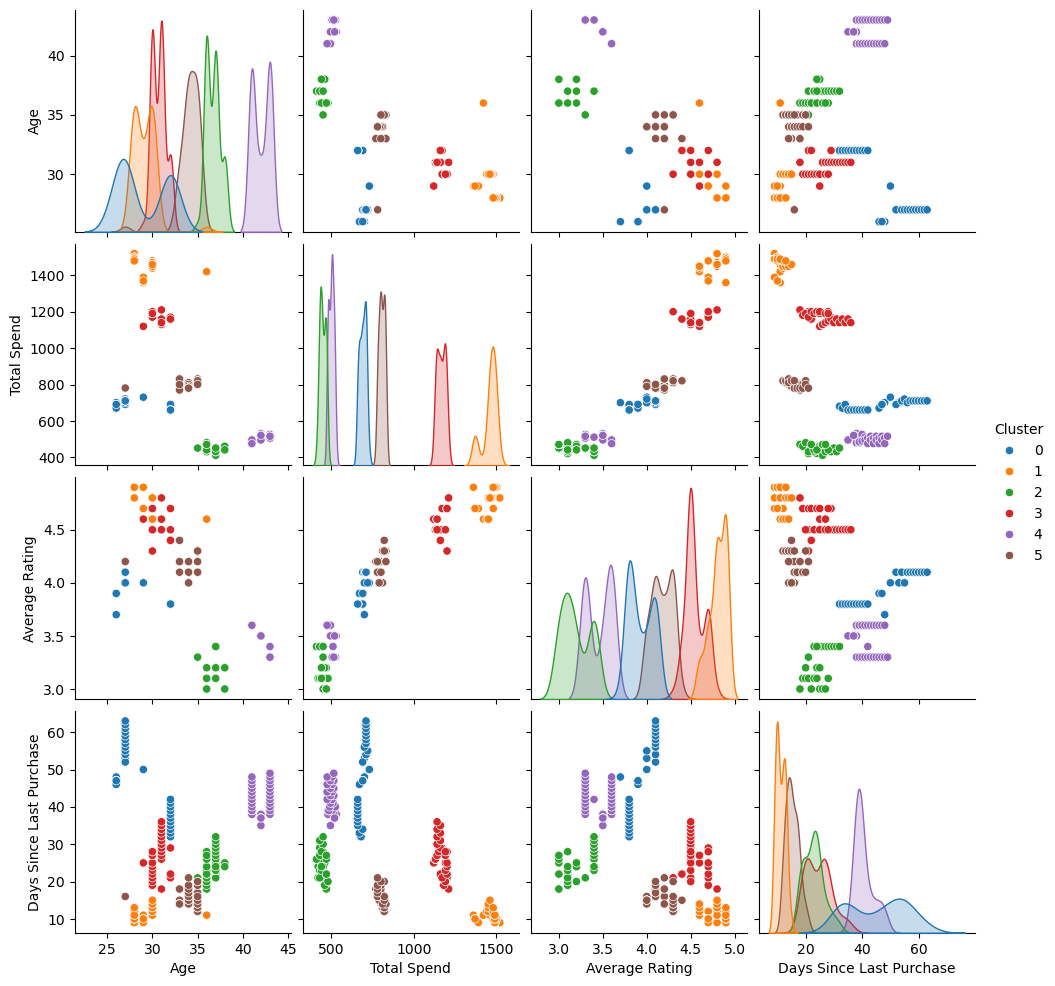

In [58]:
print("Number of features used by K-means:", kmeans_final.n_features_in_)
print("Feature names in order:")
print(features.columns.tolist())           # features is the dataframe right before scaling (defined in an earlier cell)

Number of features used by K-means: 10
Feature names in order:
['Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']
